--- Step 1: Evaluating Perceptron on Logic Gates ---


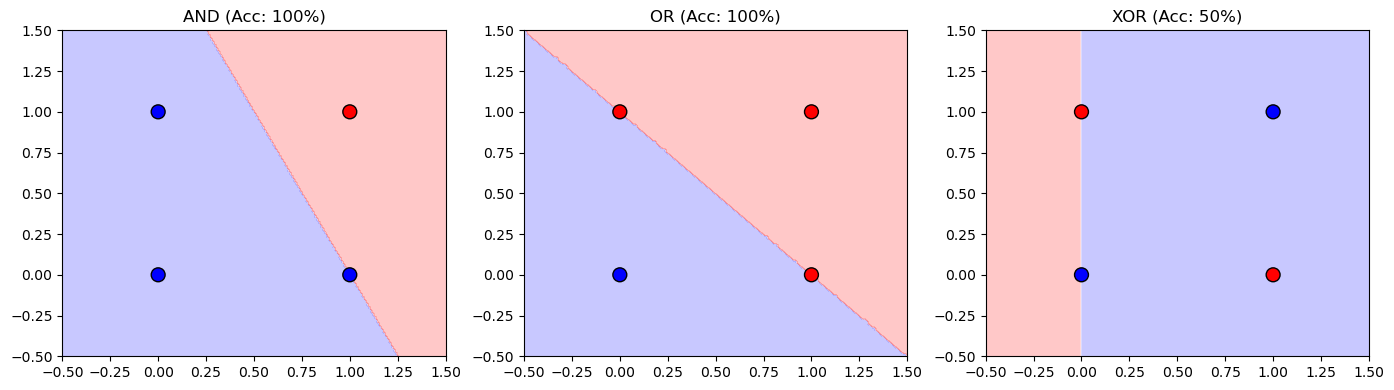

--- Step 2: Running Numerical Gradient Check ---
Param W1 | Rel Error: 4.842481e-09 | PASS
Param b1 | Rel Error: 2.287488e-09 | PASS
Param W2 | Rel Error: 7.607592e-10 | PASS
Param b2 | Rel Error: 1.261505e-09 | PASS
All parameters passed gradient verification.

--- Step 3: Decision Boundaries for Hidden Sizes (2, 8, 32) ---


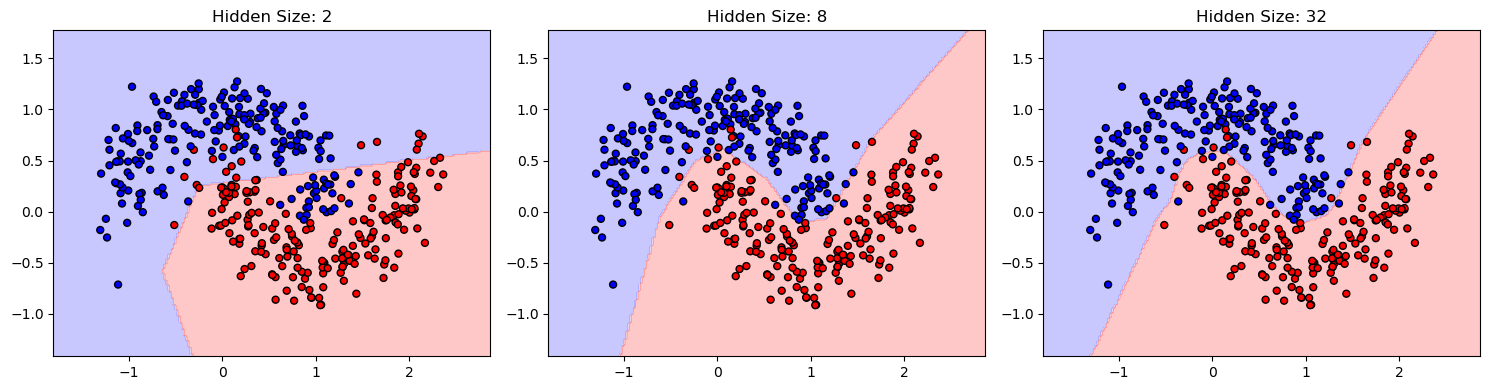

--- Step 4: Initial dW1 Gradient Divergence: 3.122502e-17 ---
Max Loss Difference Across 300 Epochs: 2.220446e-16


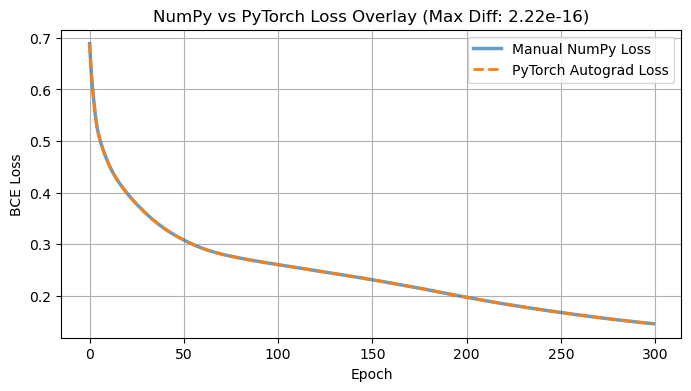

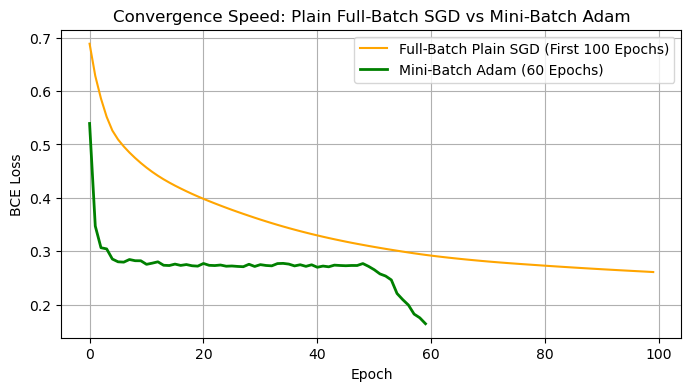

Day 1 Complete!


In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons

# =====================================================================
# 0. Global Setup & Reproducibility
# =====================================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)

# =====================================================================
# 1. Perceptron: Step Activation on AND, OR, XOR
# =====================================================================
class Perceptron:
    def __init__(self, input_dim=2, lr=0.1, epochs=30):
        self.w = np.zeros(input_dim, dtype=np.float64)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs

    def step(self, x):
        return np.where(x >= 0.0, 1.0, 0.0)

    def predict(self, X):
        return self.step(np.dot(X, self.w) + self.b)

    def train(self, X, y):
        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                y_hat = self.step(np.dot(xi, self.w) + self.b)
                update = self.lr * (target - y_hat)
                self.w += update * xi
                self.b += update

print("--- Step 1: Evaluating Perceptron on Logic Gates ---")
X_logic = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)
gates = {
    "AND": np.array([0, 0, 0, 1], dtype=np.float64),
    "OR":  np.array([0, 1, 1, 1], dtype=np.float64),
    "XOR": np.array([0, 1, 1, 0], dtype=np.float64)
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (gate_name, y_gate) in zip(axes, gates.items()):
    p = Perceptron(input_dim=2, lr=0.1, epochs=30)
    p.train(X_logic, y_gate)
    preds = p.predict(X_logic)
    acc = np.mean(preds == y_gate) * 100

    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = p.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X_logic[:, 0], X_logic[:, 1], c=y_gate, cmap="bwr", edgecolors="k", s=100)
    ax.set_title(f"{gate_name} (Acc: {acc:.0f}%)")
plt.tight_layout()
plt.show()

# Why XOR Fails:
# A single-layer perceptron defines a linear hyperplane: w1*x1 + w2*x2 + b = 0.
# The XOR gate requires outputs of 1 at (0,1) and (1,0), and 0 at (0,0) and (1,1).
# No single straight line in R^2 can separate these alternating diagonal points.
# Resolving XOR requires at least one non-linear hidden layer to remap the representation space.

# =====================================================================
# 2. 2-Layer MLP from Scratch (NumPy, float64)
# =====================================================================
class TwoLayerMLPNumPy:
    def __init__(self, in_features, hidden_features, out_features=1):
        self.W1 = (np.random.randn(in_features, hidden_features) * np.sqrt(2.0 / in_features)).astype(np.float64)
        self.b1 = np.zeros((1, hidden_features), dtype=np.float64)
        self.W2 = (np.random.randn(hidden_features, out_features) * np.sqrt(2.0 / hidden_features)).astype(np.float64)
        self.b2 = np.zeros((1, out_features), dtype=np.float64)

    def relu(self, z):
        return np.maximum(0.0, z)

    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.X = X
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.y_hat = self.sigmoid(self.z2)
        return self.y_hat

    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        p = np.clip(y_pred, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p) + (1.0 - y_true) * np.log(1.0 - p))

    def backward(self, y_true):
        m = y_true.shape[0]
        # dz2 = y_hat - y
        dz2 = self.y_hat - y_true
        self.dW2 = np.dot(self.a1.T, dz2) / m
        self.db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * (self.z1 > 0.0).astype(np.float64)
        self.dW1 = np.dot(self.X.T, dz1) / m
        self.db1 = np.sum(dz1, axis=0, keepdims=True) / m

    def step(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2

# =====================================================================
# 3. Gradient Check (Threshold < 1e-6)
# =====================================================================
def gradient_check(model, X, y, epsilon=1e-7):
    print("--- Step 2: Running Numerical Gradient Check ---")
    model.forward(X)
    model.backward(y)

    params = [model.W1, model.b1, model.W2, model.b2]
    grads = [model.dW1, model.db1, model.dW2, model.db2]
    param_names = ["W1", "b1", "W2", "b2"]

    all_passed = True
    for p, grad, name in zip(params, grads, param_names):
        num_grad = np.zeros_like(p)
        it = np.nditer(p, flags=["multi_index"], op_flags=["readwrite"])
        while not it.finished:
            idx = it.multi_index
            orig_val = p[idx]

            p[idx] = orig_val + epsilon
            loss_plus = model.compute_loss(y, model.forward(X))

            p[idx] = orig_val - epsilon
            loss_minus = model.compute_loss(y, model.forward(X))

            p[idx] = orig_val
            num_grad[idx] = (loss_plus - loss_minus) / (2.0 * epsilon)
            it.iternext()

        numerator = np.linalg.norm(grad - num_grad)
        denominator = np.linalg.norm(grad) + np.linalg.norm(num_grad)
        rel_error = numerator / (denominator + 1e-15)

        passed = rel_error < 1e-6
        all_passed = all_passed and passed
        print(f"Param {name:<2} | Rel Error: {rel_error:e} | {'PASS' if passed else 'FAIL'}")

    assert all_passed, "Gradient check failed!"
    print("All parameters passed gradient verification.\n")

# Run gradient check on toy sample
X_gc, y_gc = make_moons(n_samples=25, noise=0.2, random_state=SEED)
y_gc = y_gc.reshape(-1, 1).astype(np.float64)
gc_model = TwoLayerMLPNumPy(in_features=2, hidden_features=4)
gradient_check(gc_model, X_gc, y_gc)

# =====================================================================
# 4. Hidden Sizes Comparison on make_moons (2, 8, 32)
# =====================================================================
print("--- Step 3: Decision Boundaries for Hidden Sizes (2, 8, 32) ---")
X_moons, y_moons = make_moons(n_samples=400, noise=0.2, random_state=SEED)
y_moons = y_moons.reshape(-1, 1).astype(np.float64)

hidden_sizes = [2, 8, 32]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h_dim in zip(axes, hidden_sizes):
    h_model = TwoLayerMLPNumPy(in_features=2, hidden_features=h_dim)
    for _ in range(800):
        h_model.forward(X_moons)
        h_model.backward(y_moons)
        h_model.step(lr=0.5)

    xx, yy = np.meshgrid(np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 200),
                         np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = (h_model.forward(grid) >= 0.5).astype(int).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons.ravel(), cmap="bwr", edgecolors="k", s=25)
    ax.set_title(f"Hidden Size: {h_dim}")
plt.tight_layout()
plt.show()

# =====================================================================
# 5. Task 2: PyTorch Equivalent & Exact Alignment
# =====================================================================
class TwoLayerMLPPyTorch(nn.Module):
    def __init__(self, in_features=2, hidden_features=8, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.fc2(self.relu(self.fc1(x))))

HIDDEN_DIM = 8
EPOCHS = 300
LR = 0.5

X_torch = torch.from_numpy(X_moons).to(torch.float64)
y_torch = torch.from_numpy(y_moons).to(torch.float64)

np_model = TwoLayerMLPNumPy(in_features=2, hidden_features=HIDDEN_DIM)
pt_model = TwoLayerMLPPyTorch(in_features=2, hidden_features=HIDDEN_DIM).to(torch.float64)

# Strictly synchronize initial weights
with torch.no_grad():
    pt_model.fc1.weight.copy_(torch.from_numpy(np_model.W1.T).to(torch.float64))
    pt_model.fc1.bias.copy_(torch.from_numpy(np_model.b1.flatten()).to(torch.float64))
    pt_model.fc2.weight.copy_(torch.from_numpy(np_model.W2.T).to(torch.float64))
    pt_model.fc2.bias.copy_(torch.from_numpy(np_model.b2.flatten()).to(torch.float64))

criterion = nn.BCELoss()

# Gradient Alignment Check
np_out = np_model.forward(X_moons)
np_loss = np_model.compute_loss(y_moons, np_out)
np_model.backward(y_moons)

pt_model.zero_grad()
pt_out = pt_model(X_torch)
pt_loss = criterion(pt_out, y_torch)
pt_loss.backward()

pt_dW1 = pt_model.fc1.weight.grad.T.detach().numpy()
diff_w1 = np.max(np.abs(np_model.dW1 - pt_dW1))
print(f"--- Step 4: Initial dW1 Gradient Divergence: {diff_w1:e} ---")
assert diff_w1 < 1e-7, "Autograd and NumPy gradients do not match!"

# =====================================================================
# 6. Side-by-Side Training (Vanilla Full-Batch SGD)
# =====================================================================
np_losses, pt_losses = [], []

for _ in range(EPOCHS):
    # NumPy step
    y_hat_np = np_model.forward(X_moons)
    l_np = np_model.compute_loss(y_moons, y_hat_np)
    np_model.backward(y_moons)
    np_model.step(lr=LR)
    np_losses.append(l_np)

    # PyTorch step
    pt_model.zero_grad()
    y_hat_pt = pt_model(X_torch)
    l_pt = criterion(y_hat_pt, y_torch)
    l_pt.backward()
    with torch.no_grad():
        for param in pt_model.parameters():
            param.data -= LR * param.grad
    pt_losses.append(l_pt.item())

max_loss_diff = np.max(np.abs(np.array(np_losses) - np.array(pt_losses)))
print(f"Max Loss Difference Across {EPOCHS} Epochs: {max_loss_diff:e}")
assert max_loss_diff < 1e-5, f"Loss mismatch exceeded threshold: {max_loss_diff}"

plt.figure(figsize=(8, 4))
plt.plot(np_losses, label="Manual NumPy Loss", linewidth=2.5, alpha=0.7)
plt.plot(pt_losses, "--", label="PyTorch Autograd Loss", linewidth=2.0)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title(f"NumPy vs PyTorch Loss Overlay (Max Diff: {max_loss_diff:.2e})")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================
# 7. Modern DataLoader + Adam Convergence
# =====================================================================
loader = DataLoader(TensorDataset(X_torch, y_torch), batch_size=32, shuffle=True)
modern_model = TwoLayerMLPPyTorch(in_features=2, hidden_features=HIDDEN_DIM).to(torch.float64)
optimizer = torch.optim.Adam(modern_model.parameters(), lr=0.03)

adam_losses = []
for _ in range(60):
    epoch_loss = 0.0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        out = modern_model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    adam_losses.append(epoch_loss / len(loader.dataset))

plt.figure(figsize=(8, 4))
plt.plot(pt_losses[:100], label="Full-Batch Plain SGD (First 100 Epochs)", color="orange")
plt.plot(adam_losses, label="Mini-Batch Adam (60 Epochs)", color="green", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Convergence Speed: Plain Full-Batch SGD vs Mini-Batch Adam")
plt.legend()
plt.grid(True)
plt.show()
print("Day 1 Complete!")

Implementing a neural network from scratch in NumPy highlights just how much heavy lifting a modern automatic differentiation engine performs behind the scenes. Without autograd, every layer requires manual derivation of local gradients via the chain rule on paper, followed by careful tracking of intermediate activation caches to ensure error signals propagate backward correctly. This introduces substantial friction in matrix bookkeeping, where one must manually handle dimension alignment, matrix transpositions, and batch reductions—such as distinguishing between left- and right-multiplication when computing weight updates versus upstream error signals. Moreover, testing and maintaining architectural changes becomes tedious, as swapping an activation function or altering layer topologies demands completely rewriting the backward pass and re-verifying gradients with numerical checks. Autograd abstracts this entirely by constructing a dynamic computational graph during the forward pass and executing reverse-mode differentiation automatically, managing memory buffers and accumulating gradients directly onto parameter tensors so the practitioner can focus purely on model architecture and optimization logic.

